In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [5]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

C:\Users\USER\AppData\Local\Temp\ipykernel_17372\3256258543.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
C:\Users\USER\AppData\Local\Temp\ipykernel_17372\3256258543.py:14: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000001EFFF89FB90>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001EFFF89FB90>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000001EFFF89FB90>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000001EFFF89FB90>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000001EFFF89FB90>)]

In [7]:
# import arxiv
# from langchain_core.tools import tool

# @tool
# def search_arxiv(query: str) -> str:
#     """Search arXiv papers and return title, authors, abstract, and URL."""

#     client = arxiv.Client(
#         page_size=3,
#         delay_seconds=0.5,
#         num_retries=1,
#     )

#     clean_query = query.strip().strip('"')

#     # 유명 논문은 ID로 직접 조회
#     known_papers = {
#         "attention is all you need": "1706.03762",
#     }

#     if clean_query.lower() in known_papers:
#         search = arxiv.Search(
#             id_list=[known_papers[clean_query.lower()]],
#             max_results=1,
#         )
#     else:
#         search = arxiv.Search(
#             query=f'ti:"{clean_query}"',
#             max_results=3,
#             sort_by=arxiv.SortCriterion.Relevance,
#         )

#     results = list(client.results(search))

#     if not results:
#         return "No paper found."

#     normalized_query = clean_query.lower().strip()

#     paper = None
#     for result in results:
#         if result.title.lower().strip() == normalized_query:
#             paper = result
#             break

#     if paper is None:
#         paper = results[0]

#     return f"""
# Title: {paper.title}
# Authors: {", ".join(author.name for author in paper.authors)}
# Published: {paper.published}
# Summary: {paper.summary}
# URL: {paper.entry_id}
# """

In [8]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory = './real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to May 2026'
)

In [9]:
from langgraph.prebuilt import ToolNode

# tool_list = [add, multiply, search_tool, search_arxiv] + gmail_tool_list
tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [11]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [12]:
from langgraph.graph import START, END

def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return END

In [13]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [14]:
from langgraph.prebuilt import tools_condition

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition,
)
graph_builder.add_edge('tools', 'agent')

In [15]:
graph = graph_builder.compile()

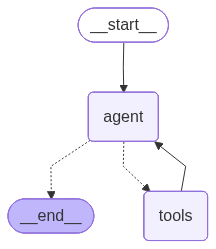

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

query = 'ajtwlsgmlwn@Naver.com 으로 최근 메이플스토리 패치노트를 요약해서 보내주세요'

for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

ajtwlsgmlwn@Naver.com 으로 최근 메이플스토리 패치노트를 요약해서 보내주세요
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_vDUbDqjfoboyG70VQf52LtzY)
 Call ID: call_vDUbDqjfoboyG70VQf52LtzY
  Args:
    query: 최근 메이플스토리 패치노트
================================= Tool Message =================================
Name: duckduckgo_search

최근 최근 방문 채널. 공지 메이플스토리 직업 공략 모음. 전체. 최근 방문. 즐겨찾기. 메이플스토리 리부트. 삭제. 메이플스토리 리부트. 본문 머리말∙꼬리말 사용. on. 메이플 코디. 메이플스토리 파트너스. AI Style Finder. 미니게임. 최근 토론.메이플 ip 로고 단풍2 데스크톱. 메이플스토리 메이플스토리. 크로스플랫폼. mmlogo 메이플스토리M. PV BTS 진이 소개하는 23주년 이벤트 - 메이플스토리.최근 HOT한 콘텐츠. 메이플. 게임.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_FWdil8aMPxW9RRIibcMm75Iw)
 Call ID: call_FWdil8aMPxW9RRIibcMm75Iw
  Args:
    query: MapleStory patch notes October 2023
================================= Tool M